# Exploratory Data Analisis (EDA)


In [1]:
# libraries
import os
import pandas as pd
import shutil
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup as bs
from chromedriver_py import binary_path
import requests
import warnings; warnings.filterwarnings("ignore")
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
players_df = pd.read_csv("raw_data/players.csv")
teams_df = pd.read_csv("raw_data/all_teams_data.csv")

# 1. Missing data

In [11]:
print(players_df.info())
print(players_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19612 entries, 0 to 19611
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  19612 non-null  object 
 1   Age     19612 non-null  int64  
 2   Team    19612 non-null  object 
 3   Pos     19612 non-null  object 
 4   G       19612 non-null  int64  
 5   GS      19612 non-null  int64  
 6   MP      19612 non-null  float64
 7   FG      19612 non-null  float64
 8   FGA     19612 non-null  float64
 9   FG%     19612 non-null  float64
 10  3P      19612 non-null  float64
 11  3PA     19612 non-null  float64
 12  3P%     19612 non-null  float64
 13  2P      19612 non-null  float64
 14  2PA     19612 non-null  float64
 15  2P%     19612 non-null  float64
 16  eFG%    19612 non-null  float64
 17  FT      19612 non-null  float64
 18  FTA     19612 non-null  float64
 19  FT%     19612 non-null  float64
 20  ORB     19612 non-null  float64
 21  DRB     19612 non-null  float64
 22

In [15]:
print(teams_df.info())
print(teams_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 909
Data columns (total 42 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Team           909 non-null    object 
 1   Year           909 non-null    int64  
 2   Champion       909 non-null    object 
 3   fg_per_g       909 non-null    float64
 4   fga_per_g      909 non-null    float64
 5   fg_pct         909 non-null    float64
 6   fg2_per_g      909 non-null    float64
 7   fg2a_per_g     909 non-null    float64
 8   fg2_pct        909 non-null    float64
 9   fg3_per_g      909 non-null    float64
 10  fg3a_per_g     909 non-null    float64
 11  fg3_pct        909 non-null    float64
 12  ft_per_g       909 non-null    float64
 13  fta_per_g      909 non-null    float64
 14  ft_pct         909 non-null    float64
 15  orb_per_g      909 non-null    float64
 16  drb_per_g      909 non-null    float64
 17  trb_per_g      909 non-null    float64
 18  ast_per_g      

In [8]:
teams = ["ATL", "BOS", "BRK", "CHI", "CHO", "CLE", "DAL", "DEN", "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHO", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"]
year=2024
for team in teams:
    team_df = pd.read_csv(f"raw_data/season_team_stats_{year}/{team}.csv")
    print(team_df.info())
    print("""
----------------------------------------------------------------------------
""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 76 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mp                    82 non-null     int64  
 1   fg                    82 non-null     int64  
 2   fga                   82 non-null     int64  
 3   fg_pct                82 non-null     float64
 4   fg3                   82 non-null     int64  
 5   fg3a                  82 non-null     int64  
 6   fg3_pct               82 non-null     float64
 7   ft                    82 non-null     int64  
 8   fta                   82 non-null     int64  
 9   ft_pct                82 non-null     float64
 10  orb                   82 non-null     int64  
 11  drb                   82 non-null     int64  
 12  trb                   82 non-null     int64  
 13  ast                   82 non-null     int64  
 14  stl                   82 non-null     int64  
 15  blk                   82 

# 2. Correlation analysis

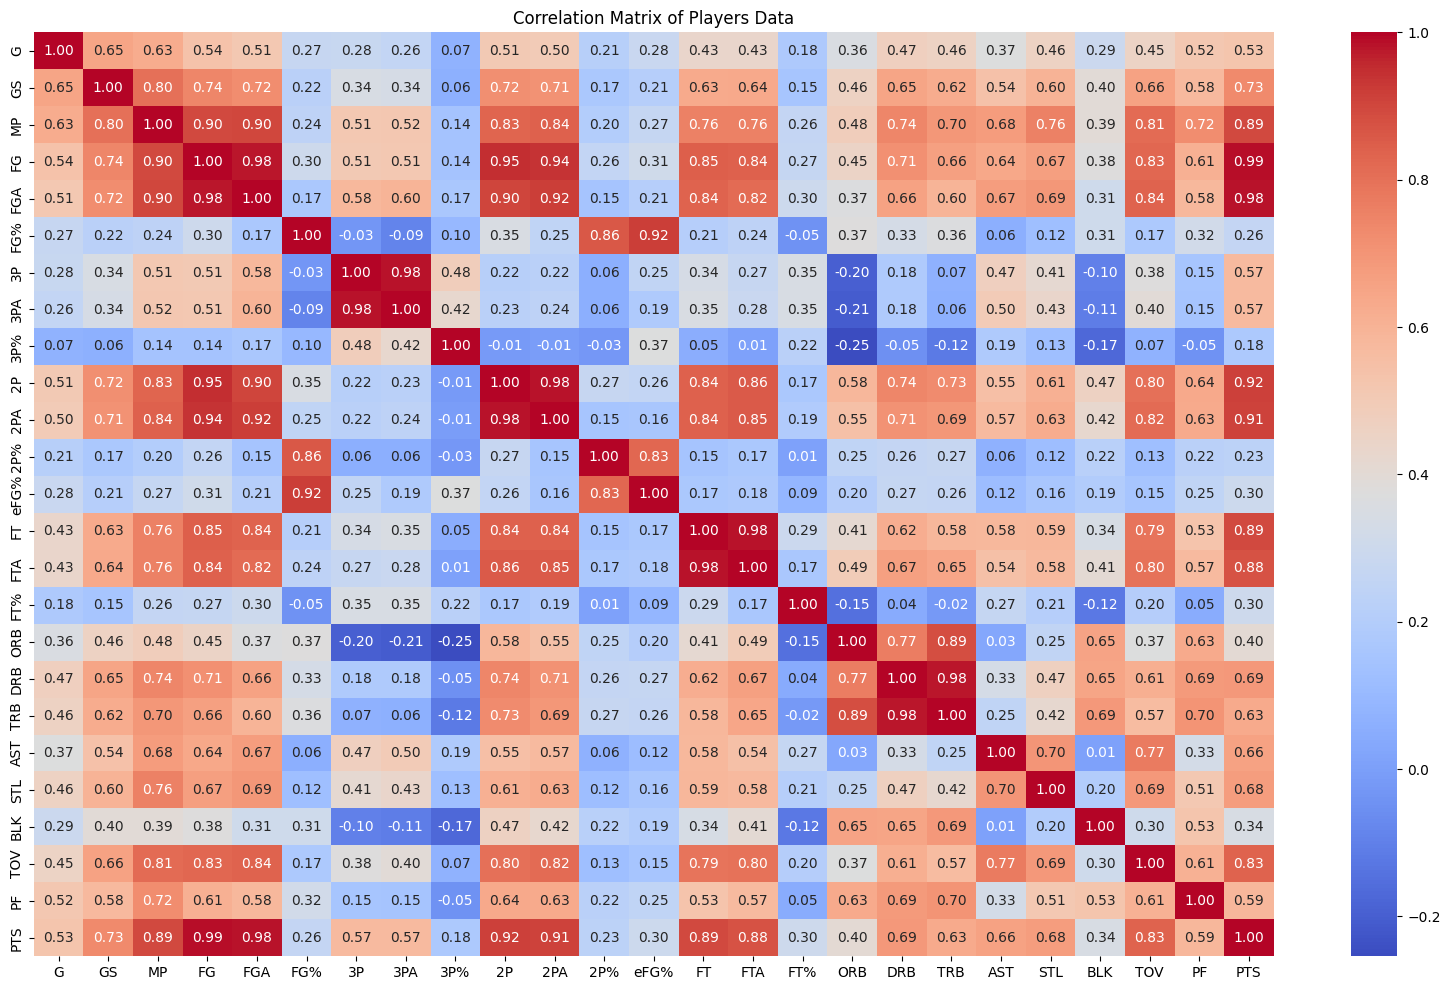

In [ ]:
players_df = players_df.drop(columns=['Rk', "Age", "Year"])
correlation_matrix_players = players_df.corr(numeric_only=True)

plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix_players, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Players Data')
plt.show()

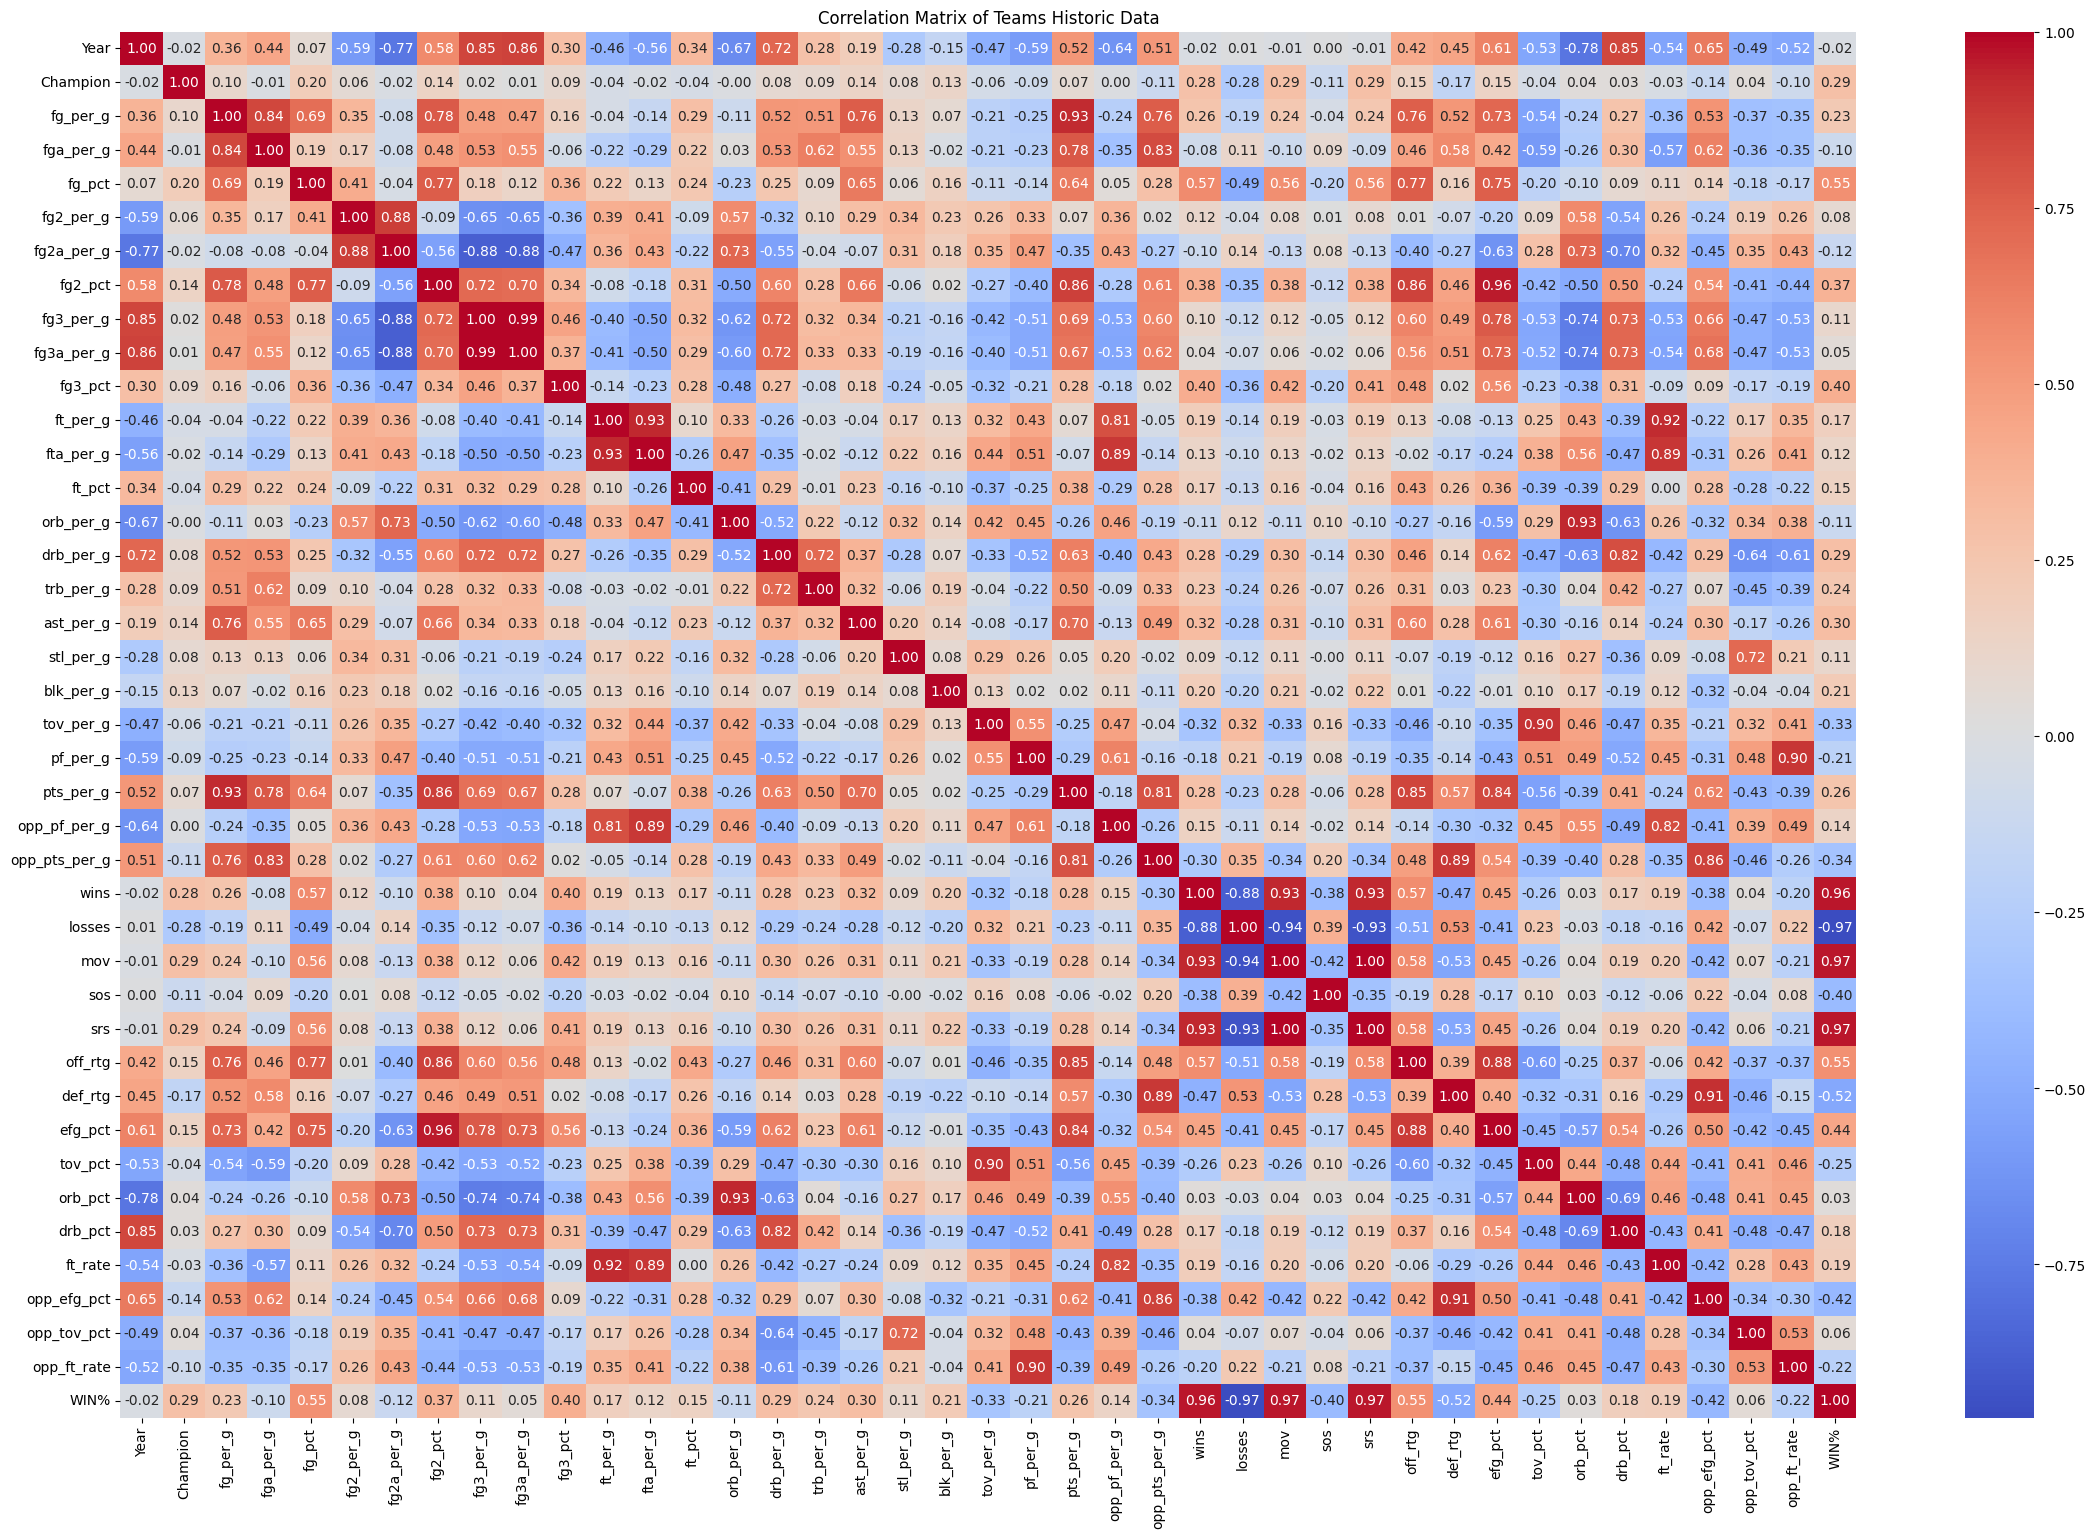

In [ ]:
teams_df["Champion"] = teams_df["Champion"].replace({"Yes": 1, "No": 0})

correlation_matrix_teams = teams_df.corr(numeric_only=True)

plt.figure(figsize=(28, 18))
sns.heatmap(correlation_matrix_teams, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Teams Historic Data')
plt.show()

# 3. Canonical Correlation Analysis (CCA)

In [4]:
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

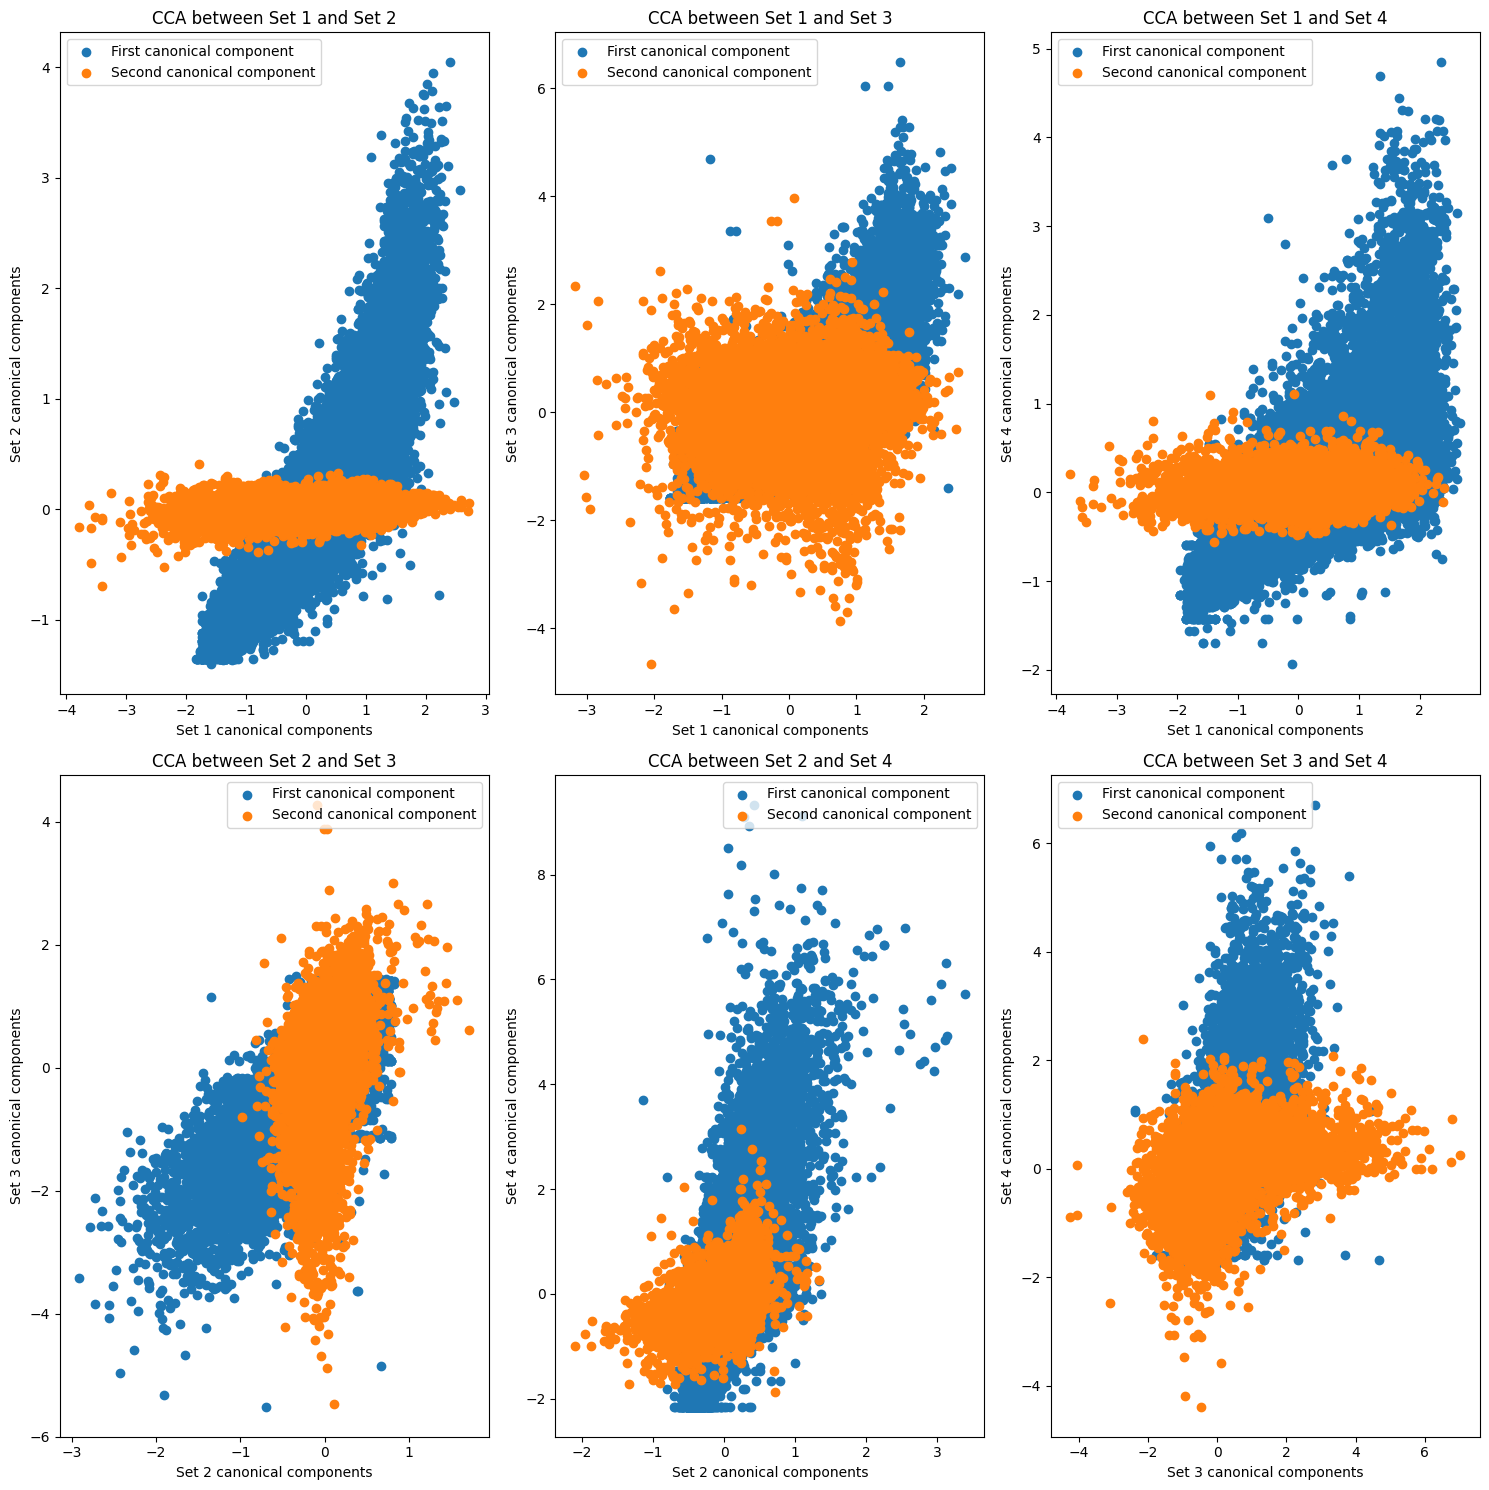

In [4]:
set1 = players_df[['G','GS','MP']]
set2 = players_df[['PTS', 'FG', 'FGA', '2P', '2PA', 'FT', 'FTA']]
set3 = players_df[['AST', 'TOV']]
set4 = players_df[['TRB', 'ORB', 'DRB']]

scaler = StandardScaler()
set1_scaled = scaler.fit_transform(set1)
set2_scaled = scaler.fit_transform(set2)
set3_scaled = scaler.fit_transform(set3)
set4_scaled = scaler.fit_transform(set4)

cca12 = CCA(n_components=2)
set1_c12, set2_c12 = cca12.fit_transform(set1_scaled, set2_scaled)

cca13 = CCA(n_components=2)
set1_c13, set3_c13 = cca13.fit_transform(set1_scaled, set3_scaled)

cca14 = CCA(n_components=2)
set1_c14, set4_c14 = cca14.fit_transform(set1_scaled, set4_scaled)

cca23 = CCA(n_components=2)
set2_c23, set3_c23 = cca23.fit_transform(set2_scaled, set3_scaled)

cca24 = CCA(n_components=2)
set2_c24, set4_c24 = cca24.fit_transform(set2_scaled, set4_scaled)

cca34 = CCA(n_components=2)
set3_c34, set4_c34 = cca34.fit_transform(set3_scaled, set4_scaled)

plt.figure(figsize=(15, 15))

# CCA Set 1 - Set 2
plt.subplot(2, 3, 1)
plt.scatter(set1_c12[:, 0], set2_c12[:, 0], label='First canonical component')
plt.scatter(set1_c12[:, 1], set2_c12[:, 1], label='Second canonical component')
plt.xlabel('Set 1 canonical components')
plt.ylabel('Set 2 canonical components')
plt.legend()
plt.title('CCA between Set 1 and Set 2')

# CCA Set 1 - Set 3
plt.subplot(2, 3, 2)
plt.scatter(set1_c13[:, 0], set3_c13[:, 0], label='First canonical component')
plt.scatter(set1_c13[:, 1], set3_c13[:, 1], label='Second canonical component')
plt.xlabel('Set 1 canonical components')
plt.ylabel('Set 3 canonical components')
plt.legend()
plt.title('CCA between Set 1 and Set 3')

# CCA Set 1 - Set 4
plt.subplot(2, 3, 3)
plt.scatter(set1_c14[:, 0], set4_c14[:, 0], label='First canonical component')
plt.scatter(set1_c14[:, 1], set4_c14[:, 1], label='Second canonical component')
plt.xlabel('Set 1 canonical components')
plt.ylabel('Set 4 canonical components')
plt.legend()
plt.title('CCA between Set 1 and Set 4')

# CCA Set 2 - Set 3
plt.subplot(2, 3, 4)
plt.scatter(set2_c23[:, 0], set3_c23[:, 0], label='First canonical component')
plt.scatter(set2_c23[:, 1], set3_c23[:, 1], label='Second canonical component')
plt.xlabel('Set 2 canonical components')
plt.ylabel('Set 3 canonical components')
plt.legend()
plt.title('CCA between Set 2 and Set 3')

# CCA Set 2 - Set 4
plt.subplot(2, 3, 5)
plt.scatter(set2_c24[:, 0], set4_c24[:, 0], label='First canonical component')
plt.scatter(set2_c24[:, 1], set4_c24[:, 1], label='Second canonical component')
plt.xlabel('Set 2 canonical components')
plt.ylabel('Set 4 canonical components')
plt.legend()
plt.title('CCA between Set 2 and Set 4')

# CCA Set 3 - Set 4
plt.subplot(2, 3, 6)
plt.scatter(set3_c34[:, 0], set4_c34[:, 0], label='First canonical component')
plt.scatter(set3_c34[:, 1], set4_c34[:, 1], label='Second canonical component')
plt.xlabel('Set 3 canonical components')
plt.ylabel('Set 4 canonical components')
plt.legend()
plt.title('CCA between Set 3 and Set 4')

plt.tight_layout()
plt.show()

In [5]:
for (cca, X, Y, name) in [
    (cca12, set1_scaled, set2_scaled, "Set 1 - Set 2"),
    (cca13, set1_scaled, set3_scaled, "Set 1 - Set 3"),
    (cca14, set1_scaled, set4_scaled, "Set 1 - Set 4"),
    (cca23, set2_scaled, set3_scaled, "Set 2 - Set 3"),
    (cca24, set2_scaled, set4_scaled, "Set 2 - Set 4"),
    (cca34, set3_scaled, set4_scaled, "Set 3 - Set 4"),
]:
    print(f"Correlaciones canónicas para {name}: {cca.score(X, Y)}")

Correlaciones canónicas para Set 1 - Set 2: -1.7891374166787437
Correlaciones canónicas para Set 1 - Set 3: 0.3774354217777519
Correlaciones canónicas para Set 1 - Set 4: -6.285612424647625
Correlaciones canónicas para Set 2 - Set 3: 0.5537850700867697
Correlaciones canónicas para Set 2 - Set 4: 0.3205808660647035
Correlaciones canónicas para Set 3 - Set 4: 0.04905073127972507


In [6]:
import numpy as np

def compute_canonical_correlations(cca, X, Y):
    X_c, Y_c = cca.transform(X, Y)
    return np.corrcoef(X_c.T, Y_c.T).diagonal(offset=X_c.shape[1])

for (cca, X, Y, name) in [
    (cca12, set1_scaled, set2_scaled, "Set 1 - Set 2"),
    (cca13, set1_scaled, set3_scaled, "Set 1 - Set 3"),
    (cca14, set1_scaled, set4_scaled, "Set 1 - Set 4"),
    (cca23, set2_scaled, set3_scaled, "Set 2 - Set 3"),
    (cca24, set2_scaled, set4_scaled, "Set 2 - Set 4"),
    (cca34, set3_scaled, set4_scaled, "Set 3 - Set 4"),
]:
    canonical_corrs = compute_canonical_correlations(cca, X, Y)
    print(f"Correlaciones canónicas para {name}: {canonical_corrs}")

Correlaciones canónicas para Set 1 - Set 2: [0.90821686 0.24930546]
Correlaciones canónicas para Set 1 - Set 3: [0.82148943 0.02651565]
Correlaciones canónicas para Set 1 - Set 4: [0.75914862 0.11843377]
Correlaciones canónicas para Set 2 - Set 3: [0.86265801 0.39861159]
Correlaciones canónicas para Set 2 - Set 4: [0.78161223 0.57906411]
Correlaciones canónicas para Set 3 - Set 4: [0.65416343 0.40183375]


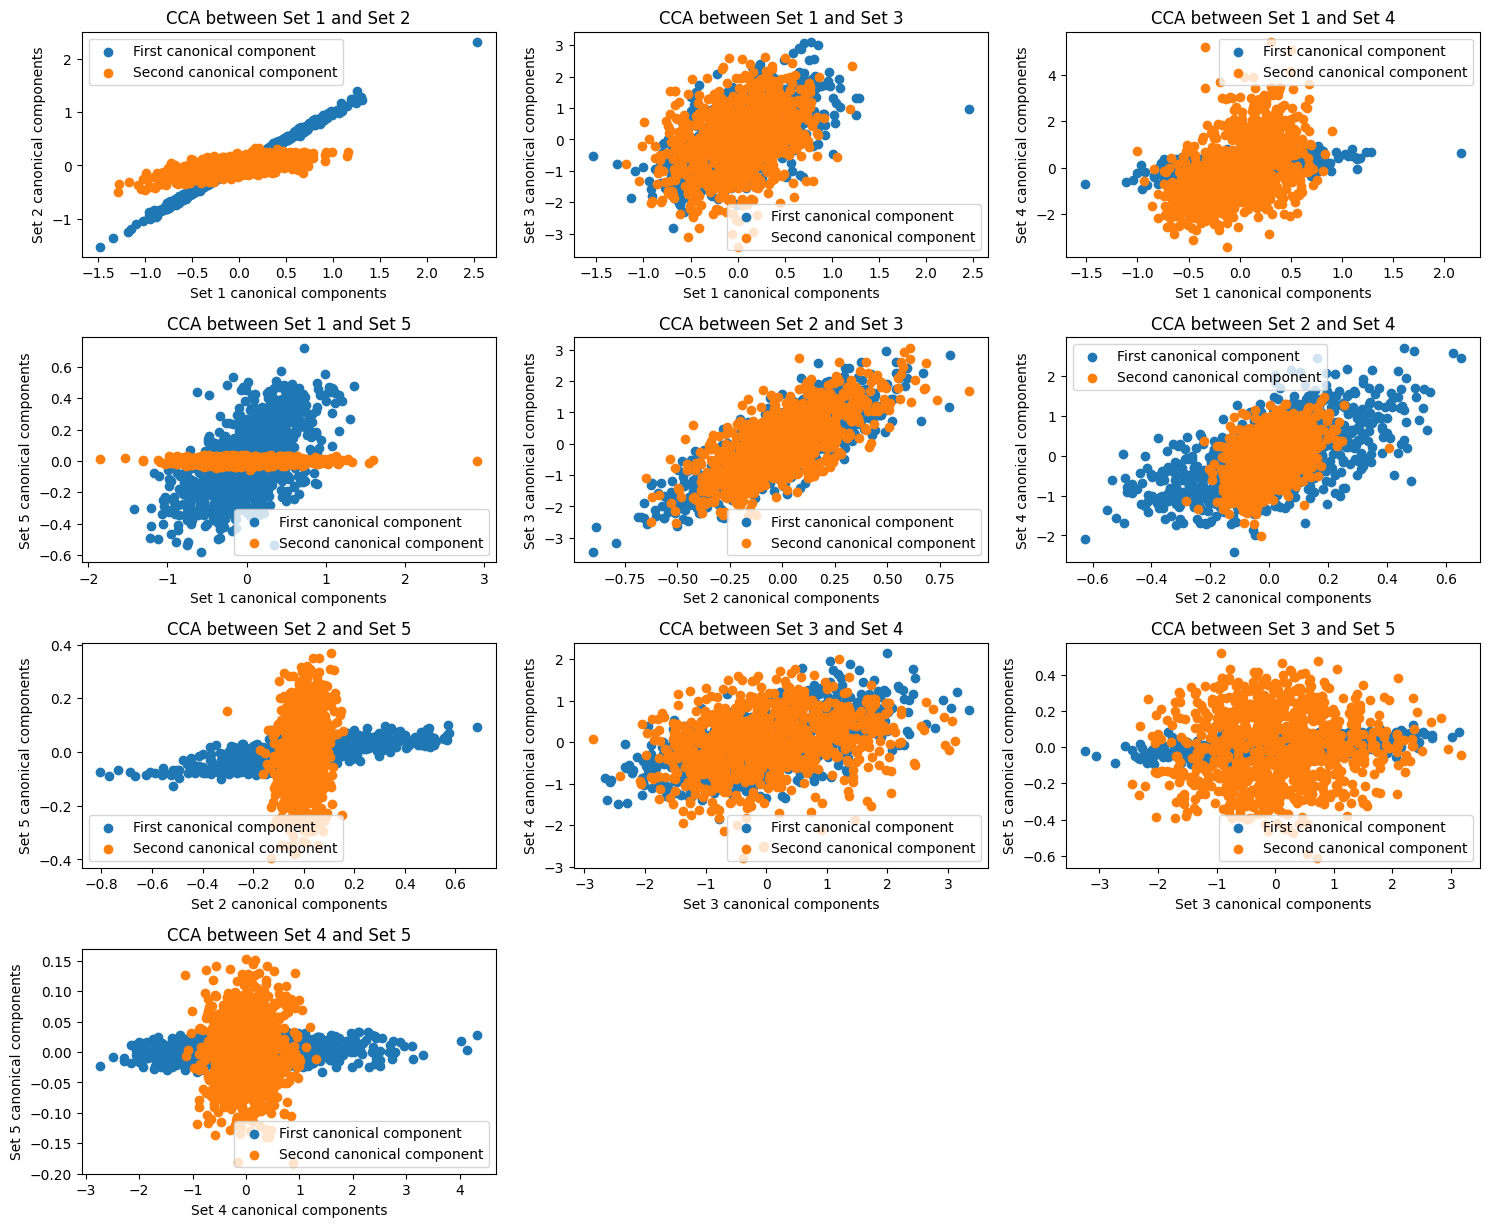

In [25]:
# Fill missing values with the mean of the respective columns
teams_df = teams_df.fillna(teams_df.mean(numeric_only=True))
# teams_df = teams_df[teams_df["Year"]>=2019]

set1 = teams_df[['def_rtg', 'opp_pts_per_g', 'opp_efg_pct']]
set2 = teams_df[['pts_per_g', 'fg_per_g', 'fga_per_g', 'fg2_per_g', 'fg2a_per_g', 'fg3_per_g', 'fg3a_per_g', 'off_rtg']]
set3 = teams_df[['ast_per_g', 'tov_per_g']]
set4 = teams_df[['pf_per_g', 'opp_ft_rate']]
set5 = teams_df[['mov', 'sos', 'srs', 'WIN%']]
sets = [set1, set2, set3, set4, set5]
set_scaled = []

scaler = StandardScaler()
for set_ in sets:
    set_scaled.append(scaler.fit_transform(set_))

cca = []

for i in range(5):
    for j in range(i+1, 5):
        cca.append(CCA(n_components=2))
        cca[-1].fit(set_scaled[i], set_scaled[j])

plt.figure(figsize=(15, 15))

plot_index = 1
for i in range(5):
    for j in range(i+1, 5):
        set_i_c, set_j_c = cca[plot_index-1].transform(set_scaled[i], set_scaled[j])
        plt.subplot(5, 3, plot_index)
        plt.scatter(set_i_c[:, 0], set_j_c[:, 0], label='First canonical component')
        plt.scatter(set_i_c[:, 1], set_j_c[:, 1], label='Second canonical component')
        plt.xlabel(f'Set {i+1} canonical components')
        plt.ylabel(f'Set {j+1} canonical components')
        plt.legend()
        plt.title(f'CCA between Set {i+1} and Set {j+1}')
        plot_index += 1

plt.tight_layout()
plt.show()

In [21]:
for (cca, X, Y, name) in [
    (cca[0], set_scaled[0], set_scaled[1], "Set 1 - Set 2"),
    (cca[1], set_scaled[0], set_scaled[2], "Set 1 - Set 3"),
    (cca[2], set_scaled[0], set_scaled[3], "Set 1 - Set 4"),
    (cca[3], set_scaled[0], set_scaled[4], "Set 1 - Set 5"),
    (cca[4], set_scaled[1], set_scaled[2], "Set 2 - Set 3"),
    (cca[5], set_scaled[1], set_scaled[3], "Set 2 - Set 4"),
    (cca[6], set_scaled[1], set_scaled[4], "Set 2 - Set 5"),
    (cca[7], set_scaled[2], set_scaled[3], "Set 3 - Set 4"),
    (cca[8], set_scaled[2], set_scaled[4], "Set 3 - Set 5"),
    (cca[9], set_scaled[3], set_scaled[4], "Set 4 - Set 5"),
]:
    canonical_corrs = compute_canonical_correlations(cca, X, Y)
    print(f"Correlaciones canónicas para {name}: {canonical_corrs}")

Correlaciones canónicas para Set 1 - Set 2: [0.9988585 0.3678178]
Correlaciones canónicas para Set 1 - Set 3: [0.48211109 0.10311862]
Correlaciones canónicas para Set 1 - Set 4: [0.60958161 0.26170186]
Correlaciones canónicas para Set 1 - Set 5: [0.68521891 0.15361953]
Correlaciones canónicas para Set 2 - Set 3: [0.79252188 0.68851822]
Correlaciones canónicas para Set 2 - Set 4: [0.6366648  0.21496651]
Correlaciones canónicas para Set 2 - Set 5: [0.75047267 0.29056962]
Correlaciones canónicas para Set 3 - Set 4: [0.47262878 0.09127403]
Correlaciones canónicas para Set 3 - Set 5: [0.48760206 0.08597531]
Correlaciones canónicas para Set 4 - Set 5: [0.25234927 0.10376391]


# 4. Missing data treatment

In [ ]:
teams_df = teams_df.drop(columns=['W', "L"])
teams_df["Champion"] = teams_df["Champion"].replace({"Yes": 1, "No": 0})
teams_df = teams_df.dropna()
teams_df


,Team,Year,Champion,fg_per_g,fga_per_g,fg_pct,fg2_per_g,fg2a_per_g,fg2_pct,fg3_per_g,...,def_rtg,efg_pct,tov_pct,orb_pct,drb_pct,ft_rate,opp_efg_pct,opp_tov_pct,opp_ft_rate,WIN%
0,ATL,1991,0,40.8,88.1,0.464,37.5,77.9,0.482,3.3,...,110.1,0.482,12.9,33.1,69.1,0.282,0.509,13.7,0.220,0.524390
1,ATL,1992,0,42.6,91.2,0.467,40.0,83.0,0.482,2.6,...,108.9,0.481,13.0,33.6,68.3,0.203,0.497,13.2,0.209,0.463415
2,ATL,1993,0,41.4,88.7,0.466,36.7,75.6,0.486,4.7,...,110.2,0.493,14.0,34.8,68.5,0.227,0.516,14.6,0.224,0.524390
3,ATL,1994,0,39.6,85.8,0.461,36.3,75.7,0.480,3.3,...,101.7,0.480,13.6,34.6,67.7,0.221,0.475,16.0,0.185,0.695122
4,ATL,1995,0,36.4,81.5,0.447,29.8,62.2,0.480,6.6,...,105.2,0.487,13.9,31.6,68.4,0.211,0.495,15.6,0.215,0.512195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,WAS,2020,0,41.5,90.9,0.457,29.5,58.3,0.506,12.0,...,115.5,0.523,12.2,22.2,75.3,0.213,0.558,13.9,0.231,0.347222
905,WAS,2021,0,43.2,90.9,0.475,33.0,61.9,0.533,10.2,...,113.0,0.531,12.3,21.3,77.6,0.221,0.539,12.5,0.217,0.472222
906,WAS,2022,0,40.6,86.0,0.472,30.1,55.4,0.543,10.5,...,114.5,0.532,12.1,20.9,76.9,0.197,0.529,10.7,0.202,0.426829
907,WAS,2023,0,42.1,86.9,0.485,30.9,55.2,0.559,11.3,...,115.6,0.550,12.7,22.6,76.1,0.202,0.540,11.0,0.194,0.426829


In [ ]:
players_df = players_df.drop(columns=['Rk'])
players_df = players_df.fillna(0)
players_df["Awards"] = players_df["Awards"].replace({0: ""})
players_df

,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Year
0,Michael Jordan,27,CHI,SG,82,82,37.0,12.1,22.4,0.539,...,4.6,6.0,5.5,2.7,1.0,2.5,2.8,31.5,"MVP-1,DPOY-7,AS,NBA1",1991
1,Karl Malone,27,UTA,PF,82,82,40.3,10.3,19.6,0.527,...,8.9,11.8,3.3,1.1,1.0,3.0,3.3,29.0,"MVP-5,AS,NBA1",1991
2,Bernard King,34,WSB,SF,64,64,37.5,11.1,23.6,0.472,...,3.2,5.0,4.6,0.9,0.3,4.0,2.9,28.4,"MVP-16,AS,NBA3",1991
3,Charles Barkley,27,PHI,SF,67,67,37.3,9.9,17.4,0.570,...,6.3,10.1,4.2,1.6,0.5,3.1,2.6,27.6,"MVP-4,AS,NBA1",1991
4,Patrick Ewing,28,NYK,C,81,81,38.3,10.4,20.3,0.514,...,8.8,11.2,3.0,1.0,3.2,3.6,3.5,26.6,"MVP-11,DPOY-7,AS,NBA2",1991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19607,Danny Green,36,PHI,SG,2,0,9.0,0.0,1.0,0.000,...,1.0,1.0,0.5,0.5,0.0,0.0,0.5,0.0,,2024
19608,Ron Harper Jr.,23,TOR,PF,1,0,4.0,0.0,0.0,0.000,...,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,,2024
19609,Justin Jackson,28,MIN,SF,2,0,0.5,0.0,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,2024
19610,Dmytro Skapintsev,25,NYK,C,2,0,1.0,0.0,0.5,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,,2024


In [7]:
teams = ["ATL", "BOS", "BRK", "CHI", "CHO", "CLE", "DAL", "DEN", "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHO", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"]
year=2024
for team in teams:
    team_df = pd.read_csv(f"raw_data/season_team_stats_{year}/{team}.csv")
    team_df = team_df.drop(columns=['game_score', 'plus_minus', 'bpm', 'opp_game_score', 'opp_plus_minus', 'opp_bpm', "opp_Location", "mp", "opp_mp", "usg_pct", "opp_usg_pct"])
    team_df = team_df.fillna(0)
    team_df.to_csv(f"raw_data/season_team_stats_{year}/{team}.csv", index=False)
    print(team_df.info())
    print("""
----------------------------------------------------------------------------
""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fg                    82 non-null     int64  
 1   fga                   82 non-null     int64  
 2   fg_pct                82 non-null     float64
 3   fg3                   82 non-null     int64  
 4   fg3a                  82 non-null     int64  
 5   fg3_pct               82 non-null     float64
 6   ft                    82 non-null     int64  
 7   fta                   82 non-null     int64  
 8   ft_pct                82 non-null     float64
 9   orb                   82 non-null     int64  
 10  drb                   82 non-null     int64  
 11  trb                   82 non-null     int64  
 12  ast                   82 non-null     int64  
 13  stl                   82 non-null     int64  
 14  blk                   82 non-null     int64  
 15  tov                   82 

In [ ]:
players_df.to_csv("raw_data/players.csv", index=False)
teams_df.to_csv("raw_data/all_teams_data.csv", index=False)

# 5. Dimensionality reduction

In [8]:
players_df = pd.read_csv("raw_data/players.csv")
teams_df = pd.read_csv("raw_data/all_teams_data.csv")

In [9]:
group1 = ["GS", "G", "MP"]
group2 = ["PTS", "FG", "FGA", "2P", "2PA", "FT", "FTA"]
group3 = ["AST", "TOV", "STL", "PF"]
group4 = ["TRB", "ORB", "DRB", "BLK"]
group5 = ["3P", "3PA", "3P%"]
group6 = ["2P%", "FG%", "eFG%"]
columns_not_pca = ["Player", "Year", "Team", "Pos", "Age", "Awards"]
not_pca_df = players_df[columns_not_pca]

scaler1 = StandardScaler().fit_transform(players_df[group1])
scaler2 = StandardScaler().fit_transform(players_df[group2])
scaler3 = StandardScaler().fit_transform(players_df[group3])
scaler4 = StandardScaler().fit_transform(players_df[group4])
scaler5 = StandardScaler().fit_transform(players_df[group5])
scaler6 = StandardScaler().fit_transform(players_df[group6])

pca1 = PCA(n_components=0.90)
pca2 = PCA(n_components=0.90)
pca3 = PCA(n_components=0.90)
pca4 = PCA(n_components=0.90)
pca5 = PCA(n_components=0.90)
pca6 = PCA(n_components=0.90)

group1_reduced = pca1.fit_transform(scaler1)
group2_reduced = pca2.fit_transform(scaler2)
group3_reduced = pca3.fit_transform(scaler3)
group4_reduced = pca4.fit_transform(scaler4)
group5_reduced = pca5.fit_transform(scaler5)
group6_reduced = pca6.fit_transform(scaler6)

df_pca1 = pd.DataFrame(group1_reduced, columns=[f'PCA1_{i+1}' for i in range(group1_reduced.shape[1])])
df_pca2 = pd.DataFrame(group2_reduced, columns=[f'PCA2_{i+1}' for i in range(group2_reduced.shape[1])])
df_pca3 = pd.DataFrame(group3_reduced, columns=[f'PCA3_{i+1}' for i in range(group3_reduced.shape[1])])
df_pca4 = pd.DataFrame(group4_reduced, columns=[f'PCA4_{i+1}' for i in range(group4_reduced.shape[1])])
df_pca5 = pd.DataFrame(group5_reduced, columns=[f'PCA5_{i+1}' for i in range(group5_reduced.shape[1])])
df_pca6 = pd.DataFrame(group6_reduced, columns=[f'PCA6_{i+1}' for i in range(group6_reduced.shape[1])])

players_df_reduced = pd.concat([not_pca_df, df_pca1, df_pca2, df_pca3, df_pca4, df_pca5, df_pca6], axis=1)

In [14]:
players_df_reduced.to_csv(f"procesed_data/all_players_data_reduced.csv", index=False)
players_df_reduced

,Player,Year,Team,Pos,Age,Awards,PCA1_1,PCA1_2,PCA2_1,PCA3_1,PCA3_2,PCA3_3,PCA4_1,PCA4_2,PCA5_1,PCA5_2,PCA6_1
0,Michael Jordan,1991,CHI,SG,27,"MVP-1,DPOY-7,AS,NBA1",3.066899,-0.352734,10.782749,4.836103,-0.740234,2.342104,2.023265,0.389668,-0.141630,0.539407,1.350137
1,Karl Malone,1991,UTA,PF,27,"MVP-5,AS,NBA1",3.260462,-0.492312,10.505289,2.977850,0.848702,-0.597509,5.441423,-1.332975,-0.867974,0.773790,1.087410
2,Bernard King,1991,WSB,SF,34,"MVP-16,AS,NBA3",2.332886,-0.719970,10.137484,3.603836,0.091873,-1.740274,0.982164,-0.651721,-0.832995,0.309437,0.285254
3,Charles Barkley,1991,PHI,SF,27,"MVP-4,AS,NBA1",2.448379,-0.653829,8.995075,3.524823,-0.259440,0.172254,4.451752,-1.819899,0.451173,0.028328,2.021115
4,Patrick Ewing,1991,NYK,C,28,"MVP-11,DPOY-7,AS,NBA2",3.100743,-0.426946,9.163497,3.291541,1.143740,-1.113333,7.052166,3.019489,-1.668027,-0.592162,0.885981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19607,Danny Green,2024,PHI,SG,36,NaN,-2.011540,-0.681517,-3.224727,-1.951384,-0.831595,0.747058,-1.899521,-0.017776,-1.534409,-0.672241,-6.886292
19608,Ron Harper Jr.,2024,TOR,PF,23,NaN,-2.325494,-0.501804,-3.357711,-1.639419,0.655859,-0.353866,-2.407227,0.274414,-1.701431,-0.572142,-6.886292
19609,Justin Jackson,2024,MIN,SF,28,NaN,-2.510112,-0.321997,-3.357711,-2.912761,-1.036748,-0.058510,-2.407227,0.274414,-1.701431,-0.572142,-6.886292
19610,Dmytro Skapintsev,2024,NYK,C,25,NaN,-2.480784,-0.343146,-3.266132,-2.912761,-1.036748,-0.058510,-2.407227,0.274414,-1.701431,-0.572142,-6.886292


In [12]:
group1 = ["pts_per_g", "fg_per_g", "fga_per_g", "fg2_per_g", "fg2a_per_g", "fg3_per_g", "fg3a_per_g"]
group2 = ["ast_per_g", "tov_per_g", "tov_pct", "stl_per_g", "pf_per_g", "opp_ft_rate", "opp_tov_pct"]
group3 = ["drb_per_g", "orb_per_g", "trb_per_g", "orb_pct", "drb_pct", "blk_per_g"]
group4 = ["fg_pct", "fg3_pct", "efg_pct", "fg2_pct"]
group5 = ["wins", "mov", "srs", "WIN%", "losses", "sos"]
group6 = ["ft_per_g", "fta_per_g", "ft_pct", "ft_rate", "opp_pf_per_g"]
group7 = ["def_rtg", "opp_pts_per_g", "opp_efg_pct"]
columns_not_pca = ["Team", "Year", "Champion"]
not_pca_df = teams_df[columns_not_pca]

scaler1 = StandardScaler().fit_transform(teams_df[group1])
scaler2 = StandardScaler().fit_transform(teams_df[group2])
scaler3 = StandardScaler().fit_transform(teams_df[group3])
scaler4 = StandardScaler().fit_transform(teams_df[group4])
scaler5 = StandardScaler().fit_transform(teams_df[group5])
scaler6 = StandardScaler().fit_transform(teams_df[group6])
scaler7 = StandardScaler().fit_transform(teams_df[group7])

pca1 = PCA(n_components=0.90)
pca2 = PCA(n_components=0.90)
pca3 = PCA(n_components=0.90)
pca4 = PCA(n_components=0.90)
pca5 = PCA(n_components=0.90)
pca6 = PCA(n_components=0.90)
pca7 = PCA(n_components=0.90)

group1_reduced = pca1.fit_transform(scaler1)
group2_reduced = pca2.fit_transform(scaler2)
group3_reduced = pca3.fit_transform(scaler3)
group4_reduced = pca4.fit_transform(scaler4)
group5_reduced = pca5.fit_transform(scaler5)
group6_reduced = pca6.fit_transform(scaler6)
group7_reduced = pca5.fit_transform(scaler7)

df_pca1 = pd.DataFrame(group1_reduced, columns=[f'PCA1_{i+1}' for i in range(group1_reduced.shape[1])])
df_pca2 = pd.DataFrame(group2_reduced, columns=[f'PCA2_{i+1}' for i in range(group2_reduced.shape[1])])
df_pca3 = pd.DataFrame(group3_reduced, columns=[f'PCA3_{i+1}' for i in range(group3_reduced.shape[1])])
df_pca4 = pd.DataFrame(group4_reduced, columns=[f'PCA4_{i+1}' for i in range(group4_reduced.shape[1])])
df_pca5 = pd.DataFrame(group5_reduced, columns=[f'PCA5_{i+1}' for i in range(group5_reduced.shape[1])])
df_pca6 = pd.DataFrame(group6_reduced, columns=[f'PCA6_{i+1}' for i in range(group6_reduced.shape[1])])
df_pca7 = pd.DataFrame(group7_reduced, columns=[f'PCA7_{i+1}' for i in range(group7_reduced.shape[1])])

teams_df_reduced = pd.concat([not_pca_df, df_pca1, df_pca2, df_pca3, df_pca4, df_pca5, df_pca6, df_pca7], axis=1)

In [13]:
teams_df_reduced.to_csv(f"procesed_data/all_teams_data_reduced.csv", index=False)
teams_df_reduced

,Team,Year,Champion,PCA1_1,PCA1_2,PCA2_1,PCA2_2,PCA2_3,PCA2_4,PCA3_1,PCA3_2,PCA3_3,PCA4_1,PCA4_2,PCA5_1,PCA5_2,PCA6_1,PCA6_2,PCA7_1
0,ATL,1991,0,-1.231016,3.535589,0.304099,0.978936,-0.159656,-0.207678,-2.428924,1.369847,-1.253322,-0.853500,-1.124751,0.307134,-0.059282,4.538797,1.830462,1.093902
1,ATL,1992,0,-1.612864,4.761236,0.156102,2.092932,0.846727,0.347029,-2.348084,1.888933,-2.253130,-0.963296,-1.612732,-0.831684,0.783426,-0.114166,-0.906118,0.578681
2,ATL,1993,0,-0.716421,3.223519,1.630914,2.108527,1.027062,-0.094038,-2.989905,0.856815,-2.618268,-0.007957,0.040914,-0.124569,0.522430,1.443590,-0.472133,1.212497
3,ATL,1994,0,-1.806640,2.417396,0.975019,3.925842,0.763874,-1.867335,-2.909726,1.934353,-0.345086,-1.031470,-1.096353,2.744927,-0.295099,0.203129,-0.108168,-1.716842
4,ATL,1995,0,-0.681071,-0.920722,1.355511,1.154313,-0.488430,-1.217953,-2.635223,-0.332071,-0.089047,-0.997761,-0.165458,0.381655,-0.503754,-0.279334,-1.267168,-0.888205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,WAS,2020,0,3.262172,0.907000,-0.122970,1.023618,-0.640060,1.122321,1.413505,-1.052029,-0.324588,0.925029,0.459663,-1.884646,-1.964310,0.278174,0.883726,3.623964
905,WAS,2021,0,2.705349,2.255905,-1.142169,0.242484,0.174493,1.335560,3.040890,0.312946,-0.901314,1.819657,-0.791300,-0.632816,-0.163137,0.867626,0.410118,2.837608
906,WAS,2022,0,2.255536,0.097177,-3.269890,-0.736178,0.304485,1.132796,2.612813,-0.392274,0.449292,1.795174,-1.214685,-1.406940,0.107600,-1.686807,0.656778,2.335223
907,WAS,2023,0,2.869463,0.724348,-2.667915,-0.461553,1.071849,0.802202,2.225911,0.073446,0.502613,3.044657,-1.035007,-0.991501,0.208080,-1.471439,0.837572,2.898180


In [ ]:
teams = ["ATL", "BOS", "BRK", "CHI", "CHO", "CLE", "DAL", "DEN", "DET", "GSW", "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK", "OKC", "ORL", "PHI", "PHO", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"]
year=2024
for team in teams:
    team_df = pd.read_csv(f"raw_data/season_team_stats_{year}/{team}.csv")
    group1 = ["pts", "fg", "fga", "fg3", "fg3a"]
    group2 = ["ast", "ast_pct", "tov", "tov_pct", "stl", "stl_pct", "pf", "opp_ft", "opp_fta", "opp_ft_pct", "opp_fta_per_fga_pct", "opp_tov_pct"]
    group3 = ["drb", "orb", "trb", "orb_pct", "drb_pct", "trb_pct", "blk", "blk_pct"]
    group4 = ["off_rtg", "fg_pct", "fg3_pct", "efg_pct", "ts_pct", "fg3a_per_fga_pct"]
    group5 = ["ft", "fta", "ft_pct", "fta_per_fga_pct", "opp_pf"]
    group6 = ["def_rtg", "opp_off_rtg", "opp_pts", "opp_efg_pct", "opp_fg", "opp_fga", "opp_fg_pct", "opp_fg3", "opp_fg3a", "opp_fg3_pct", "opp_ts_pct", "opp_fg3a_per_fga_pct"]
    group7 = ["opp_orb", "opp_orb_pct", "opp_drb", "opp_drb_pct", "opp_trb", "opp_trb_pct", "opp_blk", "opp_blk_pct", "opp_def_rtg"]
    group8 = [ "opp_ast", "opp_ast_pct", "opp_stl", "opp_stl_pct", "opp_tov"]
    columns_not_pca = ["opp_Opponent", "Location", "Opponent"]
    not_pca_df = team_df[columns_not_pca]

    scaler1 = StandardScaler().fit_transform(team_df[group1])
    scaler2 = StandardScaler().fit_transform(team_df[group2])
    scaler3 = StandardScaler().fit_transform(team_df[group3])
    scaler4 = StandardScaler().fit_transform(team_df[group4])
    scaler5 = StandardScaler().fit_transform(team_df[group5])
    scaler6 = StandardScaler().fit_transform(team_df[group6])
    scaler7 = StandardScaler().fit_transform(team_df[group7])
    scaler8 = StandardScaler().fit_transform(team_df[group8])

    pca1 = PCA(n_components=0.90)
    pca2 = PCA(n_components=0.90)
    pca3 = PCA(n_components=0.90)
    pca4 = PCA(n_components=0.90)
    pca5 = PCA(n_components=0.90)
    pca6 = PCA(n_components=0.75)
    pca7 = PCA(n_components=0.75)
    pca8 = PCA(n_components=0.75)

    group1_reduced = pca1.fit_transform(scaler1)
    group2_reduced = pca2.fit_transform(scaler2)
    group3_reduced = pca3.fit_transform(scaler3)
    group4_reduced = pca4.fit_transform(scaler4)
    group5_reduced = pca5.fit_transform(scaler5)
    group6_reduced = pca6.fit_transform(scaler6)
    group7_reduced = pca5.fit_transform(scaler7)
    group8_reduced = pca8.fit_transform(scaler8)

    df_pca1 = pd.DataFrame(group1_reduced, columns=[f'PCA1_{i+1}' for i in range(group1_reduced.shape[1])])
    df_pca2 = pd.DataFrame(group2_reduced, columns=[f'PCA2_{i+1}' for i in range(group2_reduced.shape[1])])
    df_pca3 = pd.DataFrame(group3_reduced, columns=[f'PCA3_{i+1}' for i in range(group3_reduced.shape[1])])
    df_pca4 = pd.DataFrame(group4_reduced, columns=[f'PCA4_{i+1}' for i in range(group4_reduced.shape[1])])
    df_pca5 = pd.DataFrame(group5_reduced, columns=[f'PCA5_{i+1}' for i in range(group5_reduced.shape[1])])
    df_pca6 = pd.DataFrame(group6_reduced, columns=[f'PCA6_{i+1}' for i in range(group6_reduced.shape[1])])
    df_pca7 = pd.DataFrame(group7_reduced, columns=[f'PCA7_{i+1}' for i in range(group7_reduced.shape[1])])
    df_pca8 = pd.DataFrame(group8_reduced, columns=[f'PCA8_{i+1}' for i in range(group8_reduced.shape[1])])

    team_df_reduced = pd.concat([not_pca_df, df_pca1, df_pca2, df_pca3, df_pca4, df_pca5, df_pca6, df_pca7, df_pca8], axis=1)
    team_df_reduced.to_csv(f"procesed_data/season_team_stats_{year}_reduced/{team}.csv", index=False)